# Atividade 5 — Diagnóstico de qualidade dos dados

**Projeto:** Recomendação de treinos personalizados em academia
**Base:** `dataset_academia.csv` (mesma base da Atividade 4, versão simulada — seed fixa 1053)
**Objetivo deste notebook:** investigar a base a fundo e registrar, com saídas visíveis, os problemas de
qualidade que orientarão o tratamento de dados do Encontro 8.

Roteiro: dimensões → dados ausentes → dados duplicados → inconsistências → desbalanceamento da classe de saída
→ representatividade / vieses.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

df = pd.read_csv("dataset_academia.csv")
df.head()

,aluno_id,idade,objetivo,nivel_experiencia,dias_disponiveis_semana,restricao_fisica,equipamento_disponivel,treino_recomendado
0,1,32,Condicionamento,Avancado,2,Nenhuma,Completo,Treino C
1,2,37,Hipertrofia,Iniciante,4,Nenhuma,Completo,Treino A
2,3,24,Condicionamento,Iniciante,3,Lombar,Limitado,Treino D
3,4,31,Emagrecimento,Iniciante,4,Joelho,Nenhum,Treino D
4,5,22,Condicionamento,Intermediario,3,Nenhuma,Completo,Treino C


## 1. Dimensões da base

Quantas linhas (registros de alunos) e colunas (atributos) a base tem, e de que tipo é cada coluna.

In [2]:
print("Linhas x Colunas:", df.shape)
print()
df.info()

Linhas x Colunas: (300, 8)

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   aluno_id                 300 non-null    int64
 1   idade                    300 non-null    int64
 2   objetivo                 300 non-null    str  
 3   nivel_experiencia        300 non-null    str  
 4   dias_disponiveis_semana  300 non-null    int64
 5   restricao_fisica         300 non-null    str  
 6   equipamento_disponivel   300 non-null    str  
 7   treino_recomendado       300 non-null    str  
dtypes: int64(3), str(5)
memory usage: 18.9 KB


**Leitura:** 300 registros e 8 colunas. `aluno_id` é só identificador (não é feature). São 6 features de
entrada (`idade`, `objetivo`, `nivel_experiencia`, `dias_disponiveis_semana`, `restricao_fisica`,
`equipamento_disponivel`) e 1 variável de saída (`treino_recomendado`). `idade` e `dias_disponiveis_semana`
são inteiros; as demais são texto (`object`).

## 2. Dados ausentes

Contagem e proporção de valores nulos por coluna.

In [3]:
ausentes = pd.DataFrame({
    "n_ausentes": df.isna().sum(),
    "pct_ausentes": (df.isna().mean() * 100).round(2),
})
ausentes

,n_ausentes,pct_ausentes
aluno_id,0,0.0
idade,0,0.0
objetivo,0,0.0
nivel_experiencia,0,0.0
dias_disponiveis_semana,0,0.0
restricao_fisica,0,0.0
equipamento_disponivel,0,0.0
treino_recomendado,0,0.0


In [4]:
print("Total de células ausentes na base:", int(df.isna().sum().sum()))

Total de células ausentes na base: 0


**Leitura:** nenhum valor ausente em nenhuma coluna (0%). **Isso é um artefato da geração sintética**, não
uma qualidade real da base: quando dados reais de alunos entrarem (formulário, planilha da recepção), é
esperado ter ausência em campos como `restricao_fisica` e `objetivo`. O pipeline de ingestão já precisa
prever esse caso.

## 3. Dados duplicados

Três checagens: (a) linhas 100% idênticas; (b) `aluno_id` repetido (duplicata por chave);
(c) linhas com o mesmo perfil e o mesmo rótulo, ignorando o `aluno_id`.

In [5]:
print("(a) Linhas 100% idênticas:", int(df.duplicated().sum()))
print("(b) aluno_id repetido:", int(df["aluno_id"].duplicated().sum()))
print("    aluno_id vai de", df.aluno_id.min(), "a", df.aluno_id.max(),
      "| sequencial e único:", bool((df.aluno_id.values == np.arange(1, len(df)+1)).all()))

sem_id = df.drop(columns=["aluno_id"])
print("(c) Linhas iguais ignorando aluno_id (todas as ocorrências):",
      int(sem_id.duplicated(keep=False).sum()),
      "| repetições extras:", int(sem_id.duplicated().sum()))

(a) Linhas 100% idênticas: 0
(b) aluno_id repetido: 0
    aluno_id vai de 1 a 300 | sequencial e único: True
(c) Linhas iguais ignorando aluno_id (todas as ocorrências): 14 | repetições extras: 7


In [6]:
# Mostra os grupos de perfil+rótulo repetidos
grupos = (df[sem_id.duplicated(keep=False)]
          .sort_values(list(sem_id.columns))
          .reset_index(drop=True))
grupos

,aluno_id,idade,objetivo,nivel_experiencia,dias_disponiveis_semana,restricao_fisica,equipamento_disponivel,treino_recomendado
0,19,16,Condicionamento,Intermediario,4,Nenhuma,Completo,Treino C
1,109,16,Condicionamento,Intermediario,4,Nenhuma,Completo,Treino C
2,191,20,Emagrecimento,Intermediario,4,Nenhuma,Completo,Treino B
3,221,20,Emagrecimento,Intermediario,4,Nenhuma,Completo,Treino B
4,288,25,Hipertrofia,Intermediario,3,Nenhuma,Completo,Treino A
5,297,25,Hipertrofia,Intermediario,3,Nenhuma,Completo,Treino A
6,55,27,Hipertrofia,Iniciante,4,Nenhuma,Limitado,Treino A
7,108,27,Hipertrofia,Iniciante,4,Nenhuma,Limitado,Treino A
8,285,28,Emagrecimento,Iniciante,3,Nenhuma,Completo,Treino B
9,292,28,Emagrecimento,Iniciante,3,Nenhuma,Completo,Treino B


**Leitura:** não há linha 100% idêntica nem `aluno_id` repetido — a chave está íntegra. Existem **7
repetições** de combinações perfil + rótulo (14 linhas envolvidas). Com apenas 6 atributos de baixa
cardinalidade (3–4 categorias cada, idade e dias em faixa estreita), **colisões de perfil são estatisticamente
esperadas e não indicam erro de coleta** — dois alunos diferentes realmente podem ter o mesmo perfil resumido.
Não serão removidas. Em dados reais, porém, esse mesmo teste serve para achar duplicata de cadastro.

## 4. Inconsistências

Grafias divergentes, valores impossíveis, unidades misturadas, tipos incorretos e divergências entre o
dicionário de dados e o que está na base.

In [7]:
for c in ["objetivo", "nivel_experiencia", "restricao_fisica", "equipamento_disponivel", "treino_recomendado"]:
    print(f"{c:24s} -> {sorted(df[c].unique())}")

objetivo                 -> ['Condicionamento', 'Emagrecimento', 'Hipertrofia']
nivel_experiencia        -> ['Avancado', 'Iniciante', 'Intermediario']
restricao_fisica         -> ['Joelho', 'Lombar', 'Nenhuma', 'Ombro']
equipamento_disponivel   -> ['Completo', 'Limitado', 'Nenhum']
treino_recomendado       -> ['Treino A', 'Treino B', 'Treino C', 'Treino D']


- **Grafia:** dentro de cada coluna os valores são consistentes (não há "Hipertrofia" vs "hipertrofia").
- **Acentuação:** `nivel_experiencia` está gravado **sem acento** (`Avancado`, `Intermediario`), enquanto o
  dicionário de dados do README usa `Avançado`/`Intermediário`. Divergência dicionário × base — risco de
  `join`/merge inconsistente quando dados reais (provavelmente acentuados) forem integrados.

In [8]:
# Valores numéricos: faixa e possíveis impossíveis
print(df[["idade", "dias_disponiveis_semana"]].describe().round(2))
print()
print("idade  -> min:", df.idade.min(), "| max:", df.idade.max(),
      "| menores de 18 (16-17):", int(df.idade.between(16, 17).sum()),
      "| >= 50:", int((df.idade >= 50).sum()))
print("dias   -> valores:", dict(df.dias_disponiveis_semana.value_counts().sort_index()))

        idade  dias_disponiveis_semana
count  300.00                   300.00
mean    29.29                     3.44
std      7.71                     1.27
min     16.00                     1.00
25%     23.00                     3.00
50%     30.00                     3.00
75%     35.00                     4.00
max     51.00                     6.00

idade  -> min: 16 | max: 51 | menores de 18 (16-17): 19 | >= 50: 2
dias   -> valores: {1: np.int64(20), 2: np.int64(51), 3: np.int64(86), 4: np.int64(78), 5: np.int64(50), 6: np.int64(15)}


- **Valores impossíveis:** nenhum. `idade` de 16 a 51 e `dias_disponiveis_semana` de 1 a 6 estão dentro do
  domínio válido.
- **Divergência doc × dado:** o dicionário documenta `idade` "16 a 65"; a base real vai só até **51**. O
  dicionário precisa ser corrigido para a faixa observada (ou os dados reais precisam cobrir a faixa toda).
- **Faixa etária sensível:** 19 registros são de menores (16–17). Não é valor inválido, mas é um grupo que,
  em dados reais, exige campo de autorização do responsável, e que está pouco representado para o modelo.
- **Tipos:** `idade` e `dias_disponiveis_semana` vêm como `int64` aqui, mas fontes reais (formulário Google,
  planilha) costumam trazer como texto ou decimal ("3 a 4 dias") — a ingestão precisa validar o tipo.

In [9]:
# Tipos ordinais tratados como nominais
print("nivel_experiencia é ORDINAL (Iniciante < Intermediário < Avançado) mas está como texto:")
print("  ", df.nivel_experiencia.dtype)
print("equipamento_disponivel é ORDINAL (Nenhum < Limitado < Completo) mas está como texto:")
print("  ", df.equipamento_disponivel.dtype)

nivel_experiencia é ORDINAL (Iniciante < Intermediário < Avançado) mas está como texto:
   str
equipamento_disponivel é ORDINAL (Nenhum < Limitado < Completo) mas está como texto:
   str


- **Tipo incorreto para modelagem:** `nivel_experiencia` e `equipamento_disponivel` têm ordem natural, mas
  estão como texto nominal. Na preparação (Encontro 8) precisam de codificação **ordinal** explícita, senão o
  modelo perde a informação de ordem.

In [10]:
# Ruído de rótulo: reproduz a regra de associação usada na geração e conta divergências
def recomenda(objetivo, nivel, dias, restricao, equip):
    if equip == "Nenhum":
        return "Treino D"
    if restricao != "Nenhuma":
        if nivel == "Iniciante" or dias <= 2:
            return "Treino D"
        if objetivo == "Emagrecimento":
            return "Treino B"
        return "Treino C"
    if objetivo == "Hipertrofia":
        if nivel == "Iniciante" and dias <= 2:
            return "Treino D"
        return "Treino A"
    if objetivo == "Emagrecimento":
        if dias <= 2:
            return "Treino D"
        return "Treino B"
    return "Treino C"

pred_regra = df.apply(lambda r: recomenda(r.objetivo, r.nivel_experiencia,
                                          r.dias_disponiveis_semana, r.restricao_fisica,
                                          r.equipamento_disponivel), axis=1)
ruido = (pred_regra != df.treino_recomendado)
print("Registros cujo rótulo contradiz a regra de associação:", int(ruido.sum()),
      f"({ruido.mean()*100:.1f}%)")

Registros cujo rótulo contradiz a regra de associação: 24 (8.0%)


- **Ruído de rótulo:** 24 registros (8,0%) têm `treino_recomendado` que **não segue** a regra que gerou a
  base — é o ruído de 8% injetado de propósito na Atividade 4 para simular exceções. Consequência prática:
  o classificador tem um teto de acurácia de ~92% nesta base, e não se deve forçar ajuste sobre essas linhas.

## 5. Desbalanceamento da variável de saída

Proporção de cada classe em `treino_recomendado`.

In [11]:
vc = df.treino_recomendado.value_counts()
balme = pd.DataFrame({"n": vc, "pct": (vc / len(df) * 100).round(1)})
print(balme)
print()
print("Razão classe maior / classe menor:", round(vc.max() / vc.min(), 2))

                     n   pct
treino_recomendado          
Treino D            92  30.7
Treino C            80  26.7
Treino A            74  24.7
Treino B            54  18.0

Razão classe maior / classe menor: 1.7


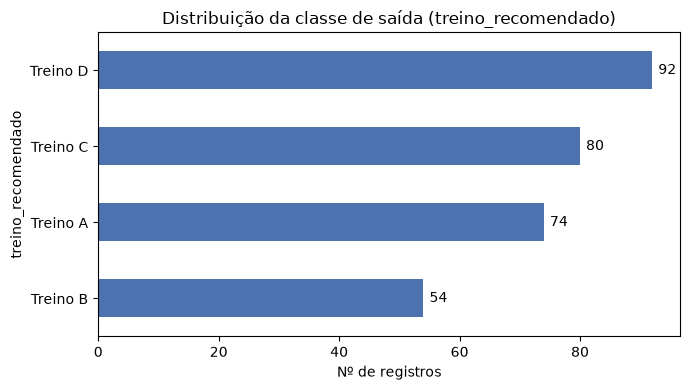

In [12]:
fig, ax = plt.subplots(figsize=(7, 4))
vc.sort_values().plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_title("Distribuição da classe de saída (treino_recomendado)")
ax.set_xlabel("Nº de registros")
for i, v in enumerate(vc.sort_values().values):
    ax.text(v + 1, i, str(v), va="center")
plt.tight_layout()
plt.savefig("grafico_desbalanceamento.png", dpi=110)
plt.show()

**Leitura:** desbalanceamento **leve**. Treino D (30,7%) é a classe mais frequente e Treino B (18,0%) a
mais rara — razão de 1,7:1. Não é um caso grave, mas o suficiente para: (a) usar `class_weight="balanced"` na
Árvore de Decisão; (b) avaliar por **F1-macro e matriz de confusão**, não só acurácia; (c) usar `stratify` no
split treino/teste para preservar a proporção.

## 6. Representatividade e vieses (dados para a discussão)

Quem a base cobre bem e quem cobre mal.

In [13]:
print("restricao_fisica:")
print((df.restricao_fisica.value_counts(normalize=True) * 100).round(1))
print("\nequipamento_disponivel:")
print((df.equipamento_disponivel.value_counts(normalize=True) * 100).round(1))
print("\nidade >= 50:", int((df.idade >= 50).sum()), "registros")
print("dias == 1:", int((df.dias_disponiveis_semana == 1).sum()),
      "| dias == 6:", int((df.dias_disponiveis_semana == 6).sum()))

restricao_fisica:
restricao_fisica
Nenhuma    69.3
Lombar     11.3
Joelho     11.3
Ombro       8.0
Name: proportion, dtype: float64

equipamento_disponivel:
equipamento_disponivel
Completo    56.0
Limitado    36.7
Nenhum       7.3
Name: proportion, dtype: float64

idade >= 50: 2 registros
dias == 1: 20 | dias == 6: 15


In [14]:
# Alunos sem equipamento: que treino recebem?
ct = pd.crosstab(df.equipamento_disponivel, df.treino_recomendado)
print(ct)
print()
print('Entre os 22 alunos "sem equipamento", a recomendação é praticamente fixa em Treino D:')
print((df[df.equipamento_disponivel == "Nenhum"].treino_recomendado.value_counts()))

treino_recomendado      Treino A  Treino B  Treino C  Treino D
equipamento_disponivel                                        
Completo                      46        37        43        42
Limitado                      27        17        36        30
Nenhum                         1         0         1        20

Entre os 22 alunos "sem equipamento", a recomendação é praticamente fixa em Treino D:
treino_recomendado
Treino D    20
Treino C     1
Treino A     1
Name: count, dtype: int64


**Leitura para a seção de vieses do relatório:**

- **Restrição física:** 69% da base é "Nenhuma"; e cada aluno só pode ter **uma** restrição — quem tem
  joelho + ombro não é representável.
- **Acesso a equipamento:** só 7,3% da base é "sem equipamento", e desses **20 de 22 caem em Treino D** por
  força da própria regra de geração. O modelo nunca vai aprender a personalizar para quem treina em casa —
  grupo que correlaciona com menor poder aquisitivo.
- **Idade:** só 2 registros com 50+ anos; nenhum acima de 51. Público idoso praticamente ausente.
- **Disponibilidade:** extremos (1 dia, 6 dias) pouco representados (~5% cada).
- **Origem do rótulo:** `treino_recomendado` **não** foi dado por um profissional de educação física — é a
  saída de uma função de regras escrita pelo autor do projeto. O modelo aprende as opiniões do autor, não
  conhecimento clínico validado.

## 7. Síntese do diagnóstico

| Eixo | Resultado |
|---|---|
| Dimensões | 300 linhas × 8 colunas |
| Ausentes | 0 (0%) — artificial da simulação |
| Duplicados | 0 linhas idênticas, 0 `aluno_id` repetido; 7 colisões de perfil (esperadas) |
| Inconsistências | acento em `nivel_experiencia` × dicionário; ordinais como texto; doc diz idade até 65, base vai até 51; 8% de ruído de rótulo |
| Desbalanceamento | leve — Treino B 18% vs Treino D 30,7% (1,7:1) |
| Viés principal | acesso a equipamento: grupo "sem equipamento" (7,3%) comprimido em Treino D pela regra de geração |

O detalhamento, a tabela de diagnóstico com gravidade/ação/prazo e a discussão de vieses estão no
`relatorio_qualidade_dados`.